In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, silhouette_score
from sklearn.cluster import AgglomerativeClustering
font_candidates = ['AppleGothic', 'Malgun Gothic', 'NanumGothic']
available_fonts = {f.name for f in fm.fontManager.ttflist}
selected_font = next((font for font in font_candidates if font in available_fonts), None)
if selected_font:
    plt.rcParams['font.family'] = selected_font
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 4)
print('selected_font:', selected_font)


selected_font: AppleGothic


## 6개 스테이션 통합 실행 Baseline: 월 군집 선택 버전

이 노트북은 6개 스테이션의 2024년 데이터를 그대로 전부 학습에 쓰지 않고, 월별 시간대 패턴을 군집화한 뒤 선택된 월만 `train / valid`에 사용하는 버전이다.

현재 기준은 다음과 같다.
- 군집 수: `k=4`
- 선택 규칙: 각 클러스터에서 대표 월 `2개`씩 선택
- 중복 월: 허용하지 않음
- 학습/검증 분리: 선택된 각 월 내부를 시간순 `7:3`
- 테스트: 2025년 전체 데이터

즉 이 파일은 `대표 월 선택 기반 통합 학습`이 실제로 일반화에 도움이 되는지 보기 위한 실험 파일이다.


In [19]:
station_info = {
    'ST-481': '상현',
    'ST-2425': '다원',
    'ST-1331': '찬솔',
    'ST-454': '신영',
    'ST-453': '혜전',
    'ST-2264': '광태',
}
station_ids = list(station_info.keys())
base_path = Path('../../../../Data/sort_data/preprocessed_6station')
feature_cols = [
    '온도', '습도', '강수량', 'snow_flag', 'is_restingday',
    'month_sin', 'month_cos', 'hour_sin', 'hour_cos'
]
static_cols = [
    '위도', '경도', 'residential_index', 'business_index',
    'tourism_index', 'transit_index', 'commute_in_index', 'commute_out_index'
]
target_col = 'total_flow'
rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [8, None],
    'min_samples_leaf': [1, 3, 5],
}
search_cv = TimeSeriesSplit(n_splits=4)
cluster_k = 4
months_per_cluster = 2
train_ratio = 0.7
print('station_ids:', station_ids)
print('target_col:', target_col)
print('cluster_k:', cluster_k)
print('months_per_cluster:', months_per_cluster)
print('train_ratio:', train_ratio)


station_ids: ['ST-481', 'ST-2425', 'ST-1331', 'ST-454', 'ST-453', 'ST-2264']
target_col: total_flow
cluster_k: 4
months_per_cluster: 2
train_ratio: 0.7


In [20]:
def load_station_csv(station_id, year_suffix=''):
    path = base_path / f'{station_id}{year_suffix}.csv'
    df = pd.read_csv(path)
    df = df.loc[~df['종료_대여소_ID'].astype(str).str.strip().str.upper().eq('X')].copy()
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
    else:
        df['기준_날짜'] = pd.to_datetime(df['기준_날짜'])
        df['timestamp'] = df['기준_날짜'] + pd.to_timedelta(df['시간대'], unit='h')
    return df

def make_station_hourly(raw_df, feature_columns, add_static=True):
    agg_map = {
        'inflow': ('station_role', lambda s: ((s == 'end') | (s == 'both')).sum()),
        'outflow': ('station_role', lambda s: ((s == 'start') | (s == 'both')).sum()),
    }
    for col in feature_columns:
        agg_map[col] = (col, 'first')
    if add_static:
        for col in static_cols:
            if col in raw_df.columns:
                agg_map[col] = (col, 'first')
    if 'station_id' in raw_df.columns:
        agg_map['station_id'] = ('station_id', 'first')
    hourly_df = raw_df.sort_values('timestamp').groupby('timestamp').agg(**agg_map)
    full_idx = pd.date_range(hourly_df.index.min(), hourly_df.index.max(), freq='h')
    hourly_df = hourly_df.reindex(full_idx)
    hourly_df.index.name = 'timestamp'
    hourly_df[['inflow', 'outflow']] = hourly_df[['inflow', 'outflow']].fillna(0)
    fill_forward_cols = [c for c in hourly_df.columns if c not in ['inflow', 'outflow']]
    for col in fill_forward_cols:
        hourly_df[col] = hourly_df[col].ffill().bfill()
    hourly_df = hourly_df.reset_index()
    hourly_df['total_flow'] = hourly_df['inflow'] + hourly_df['outflow']
    hourly_df['net_flow'] = hourly_df['inflow'] - hourly_df['outflow']
    hourly_df['month'] = hourly_df['timestamp'].dt.month
    hourly_df['hour'] = hourly_df['timestamp'].dt.hour
    return hourly_df

def build_monthly_hour_profile(station_hourly_map):
    combined_hourly_2024 = pd.concat([
        hourly.assign(source_station_id=station_id)
        for station_id, hourly in station_hourly_map.items()
    ], ignore_index=True)
    monthly_hourly_usage = (
        combined_hourly_2024
        .groupby(['month', 'hour'])['total_flow']
        .mean()
        .reset_index()
    )
    monthly_hourly_pivot = (
        monthly_hourly_usage
        .pivot(index='month', columns='hour', values='total_flow')
        .sort_index()
        .fillna(0)
    )
    return combined_hourly_2024, monthly_hourly_usage, monthly_hourly_pivot

def select_months_from_clusters(monthly_hourly_pivot, cluster_k=4, months_per_cluster=2):
    cluster_search_rows = []
    for k in range(2, min(6, len(monthly_hourly_pivot)) + 1):
        model = AgglomerativeClustering(n_clusters=k)
        labels = model.fit_predict(monthly_hourly_pivot.values)
        score = silhouette_score(monthly_hourly_pivot.values, labels) if len(set(labels)) > 1 else np.nan
        cluster_search_rows.append({'k': k, 'silhouette_score': score})
    cluster_search_df = pd.DataFrame(cluster_search_rows)

    final_model = AgglomerativeClustering(n_clusters=cluster_k)
    final_labels = final_model.fit_predict(monthly_hourly_pivot.values)
    month_cluster_df = pd.DataFrame({
        'month': monthly_hourly_pivot.index,
        'cluster': final_labels,
    })

    vectors = monthly_hourly_pivot.copy()
    month_cluster_df['distance_to_center'] = np.nan
    for cluster_id in sorted(month_cluster_df['cluster'].unique()):
        cluster_months = month_cluster_df.loc[month_cluster_df['cluster'] == cluster_id, 'month'].tolist()
        center = vectors.loc[cluster_months].mean(axis=0).values
        for month in cluster_months:
            vec = vectors.loc[month].values
            dist = float(np.linalg.norm(vec - center))
            month_cluster_df.loc[month_cluster_df['month'] == month, 'distance_to_center'] = dist

    selected_months_df = (
        month_cluster_df
        .sort_values(['cluster', 'distance_to_center', 'month'])
        .groupby('cluster', group_keys=False)
        .head(months_per_cluster)
        .sort_values(['cluster', 'distance_to_center', 'month'])
        .reset_index(drop=True)
    )
    selected_months = selected_months_df['month'].tolist()
    return cluster_search_df, month_cluster_df.sort_values(['cluster', 'month']).reset_index(drop=True), selected_months_df, selected_months

def split_selected_months(hourly_df, selected_months, train_ratio=0.7):
    train_parts = []
    valid_parts = []
    for month in selected_months:
        month_df = hourly_df.loc[hourly_df['timestamp'].dt.month == month].sort_values('timestamp').copy()
        if month_df.empty:
            continue
        if len(month_df) == 1:
            train_parts.append(month_df.copy())
            continue
        split_idx = int(len(month_df) * train_ratio)
        split_idx = min(max(split_idx, 1), len(month_df) - 1)
        train_parts.append(month_df.iloc[:split_idx].copy())
        valid_parts.append(month_df.iloc[split_idx:].copy())
    train_df = pd.concat(train_parts, ignore_index=True) if train_parts else hourly_df.iloc[0:0].copy()
    valid_df = pd.concat(valid_parts, ignore_index=True) if valid_parts else hourly_df.iloc[0:0].copy()
    return train_df, valid_df

def score_regression(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
    }


## 월별 군집화와 선택 월 구성

이 단계에서는 6개 스테이션의 2024년 시간대별 `total_flow`를 합쳐서 월별 시간대 패턴을 만든다.

그 다음 절차는 다음과 같다.
- 월별 24시간 패턴 벡터 생성
- `k=4`로 월 군집화 수행
- 각 클러스터 중심에 가까운 월 `2개`씩 선택
- 선택된 월만 각 스테이션의 `train / valid` 후보로 사용
- 같은 월이 중복 선택되는 일은 없음

주의할 점은, 실제 군집 결과에서 어떤 클러스터의 월 수가 1개뿐이면 선택 월 총수는 `8개`보다 작아질 수 있다는 점이다.
즉 이 파일은 우선 `클러스터별 최대 2개월` 규칙으로 동작한다.


In [21]:
station_hourly_2024 = {}
station_hourly_2025 = {}
station_static_map = {}

for station_id in station_ids:
    train_raw = load_station_csv(station_id, '')
    test_raw = load_station_csv(station_id, '_2025')
    train_hourly = make_station_hourly(train_raw, feature_cols, add_static=True)
    test_hourly = make_station_hourly(test_raw, feature_cols, add_static=True)
    station_static_map[station_id] = {col: train_hourly[col].iloc[0] for col in static_cols if col in train_hourly.columns}
    for col, value in station_static_map[station_id].items():
        if col not in test_hourly.columns:
            test_hourly[col] = value
    station_hourly_2024[station_id] = train_hourly
    station_hourly_2025[station_id] = test_hourly

combined_hourly_2024, monthly_hourly_usage, monthly_hourly_pivot = build_monthly_hour_profile(station_hourly_2024)
cluster_search_df, month_cluster_df, selected_months_df, selected_months = select_months_from_clusters(
    monthly_hourly_pivot,
    cluster_k=cluster_k,
    months_per_cluster=months_per_cluster,
)

print('군집 수 탐색 결과')
display(cluster_search_df.round(4))
print('월별 군집 결과')
display(month_cluster_df.round(4))
print('선택된 대표 월')
display(selected_months_df.round(4))
expected_selected_months = cluster_k * months_per_cluster
if len(selected_months) < expected_selected_months:
    print(f'warning: expected {expected_selected_months} months but selected {len(selected_months)} months because some clusters contain fewer than {months_per_cluster} months')
print('selected_months:', selected_months)

station_datasets = {}
station_split_summary = []
for station_id in station_ids:
    train_hourly = station_hourly_2024[station_id]
    test_hourly = station_hourly_2025[station_id]
    train_df, valid_df = split_selected_months(train_hourly, selected_months, train_ratio=train_ratio)
    station_datasets[station_id] = {
        'train': train_df,
        'valid': valid_df,
        'test': test_hourly,
    }
    station_split_summary.append({
        'station_id': station_id,
        'station_name': station_info[station_id],
        'selected_months': ', '.join(map(str, selected_months)),
        'train_rows': len(train_df),
        'valid_rows': len(valid_df),
        'test_rows': len(test_hourly),
        'train_start': train_df['timestamp'].min() if len(train_df) else pd.NaT,
        'train_end': train_df['timestamp'].max() if len(train_df) else pd.NaT,
        'valid_start': valid_df['timestamp'].min() if len(valid_df) else pd.NaT,
        'valid_end': valid_df['timestamp'].max() if len(valid_df) else pd.NaT,
        'test_start': test_hourly['timestamp'].min(),
        'test_end': test_hourly['timestamp'].max(),
    })
station_split_summary = pd.DataFrame(station_split_summary)
print('스테이션별 split 요약')
display(station_split_summary)



군집 수 탐색 결과


,k,silhouette_score
0,2,0.6200
1,3,0.5946
2,4,0.4385
3,5,0.4076
4,6,0.3286


월별 군집 결과


,month,cluster,distance_to_center
0,4,0,4.4507
1,5,0,3.9885
2,6,0,7.7667
3,9,0,5.3148
4,10,0,5.1089
5,3,1,3.8379
6,7,1,5.3448
7,11,1,4.0958
8,1,2,2.4676
9,2,2,2.7019


선택된 대표 월


,month,cluster,distance_to_center
0,5,0,3.9885
1,4,0,4.4507
2,3,1,3.8379
3,11,1,4.0958
4,1,2,2.4676
5,12,2,2.5917
6,8,3,0.0000


selected_months: [5, 4, 3, 11, 1, 12, 8]
스테이션별 split 요약


,station_id,station_name,selected_months,train_rows,valid_rows,test_rows,train_start,train_end,valid_start,valid_end,test_start,test_end
0,ST-481,상현,"5, 4, 3, 11, 1, 12, 8",3606,1554,8567,2024-01-01 00:00:00,2024-12-22 15:00:00,2024-01-22 16:00:00,2024-12-31 23:00:00,2025-01-09 00:00:00,2025-12-31 22:00:00
1,ST-2425,다원,"5, 4, 3, 11, 1, 12, 8",3606,1552,8567,2024-01-01 01:00:00,2024-12-22 15:00:00,2024-01-22 17:00:00,2024-12-31 22:00:00,2025-01-09 01:00:00,2025-12-31 23:00:00
2,ST-1331,찬솔,"5, 4, 3, 11, 1, 12, 8",3606,1554,8568,2024-01-01 00:00:00,2024-12-22 15:00:00,2024-01-22 16:00:00,2024-12-31 23:00:00,2025-01-09 00:00:00,2025-12-31 23:00:00
3,ST-454,신영,"5, 4, 3, 11, 1, 12, 8",3606,1554,8568,2024-01-01 00:00:00,2024-12-22 15:00:00,2024-01-22 16:00:00,2024-12-31 23:00:00,2025-01-09 00:00:00,2025-12-31 23:00:00
4,ST-453,혜전,"5, 4, 3, 11, 1, 12, 8",3606,1553,8567,2024-01-01 01:00:00,2024-12-22 15:00:00,2024-01-22 17:00:00,2024-12-31 23:00:00,2025-01-09 00:00:00,2025-12-31 22:00:00
5,ST-2264,광태,"5, 4, 3, 11, 1, 12, 8",3606,1554,8568,2024-01-01 00:00:00,2024-12-22 15:00:00,2024-01-22 16:00:00,2024-12-31 23:00:00,2025-01-09 00:00:00,2025-12-31 23:00:00


## 개별 스테이션 타깃 점검

선택된 대표 월들로 구성된 `train` 데이터를 기준으로 각 스테이션의 타깃 분포를 먼저 확인한다.
이 구간은 선택 월 기준 데이터가 특정 스테이션에 지나치게 편향되지 않았는지 보는 용도다.


6개 스테이션 전체 타깃 기술통계


,count,mean,std,min,25%,50%,75%,max
inflow,21636.0,4.909087,5.523838,0.0,0.0,3.0,7.0,43.0
outflow,21636.0,5.002496,5.570922,0.0,1.0,4.0,7.0,50.0
total_flow,21636.0,9.911583,9.725219,0.0,2.0,7.0,14.0,74.0
net_flow,21636.0,-0.093409,5.340040,-42.0,-2.0,0.0,2.0,37.0


스테이션별 평균 타깃


,station_id,inflow,outflow,total_flow,net_flow
0,ST-1331,4.3480,4.8009,9.1489,-0.4529
1,ST-2264,8.5105,8.0241,16.5347,0.4864
2,ST-2425,1.8907,2.4845,4.3752,-0.5937
3,ST-453,5.2257,4.9210,10.1467,0.3048
4,ST-454,5.5394,5.7438,11.2831,-0.2044
5,ST-481,3.9401,4.0408,7.9809,-0.1007


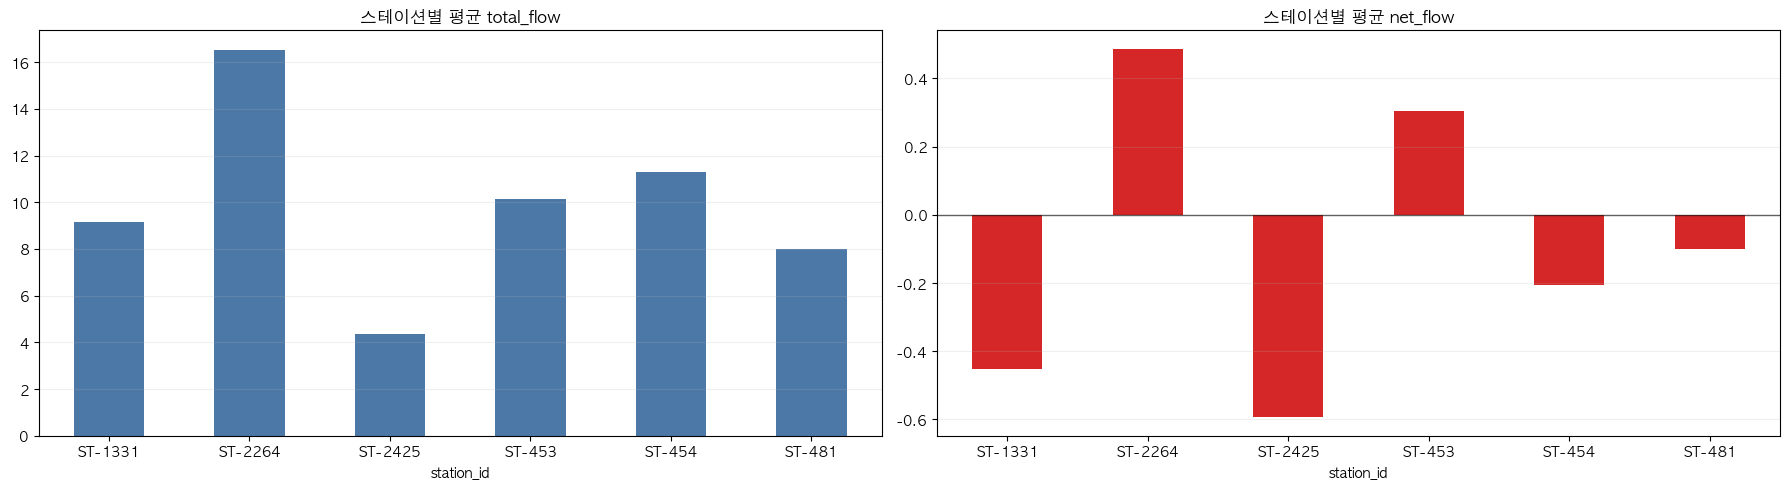

In [22]:
combined_target_view = pd.concat([
    station_datasets[s]['train'][['station_id', 'timestamp', 'inflow', 'outflow', 'total_flow', 'net_flow']]
    for s in station_ids
], ignore_index=True)

print('6개 스테이션 전체 타깃 기술통계')
display(combined_target_view[['inflow', 'outflow', 'total_flow', 'net_flow']].describe().T)

station_target_summary = (
    combined_target_view.groupby('station_id')[['inflow', 'outflow', 'total_flow', 'net_flow']]
    .mean()
    .reset_index()
)
print('스테이션별 평균 타깃')
display(station_target_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
station_target_summary.set_index('station_id')['total_flow'].plot(kind='bar', ax=axes[0], color='#4C78A8')
axes[0].set_title('스테이션별 평균 total_flow')
axes[0].grid(axis='y', alpha=0.2)
axes[0].tick_params(axis='x', rotation=0)

station_target_summary.set_index('station_id')['net_flow'].plot(kind='bar', ax=axes[1], color='#D62728')
axes[1].axhline(0, color='black', linewidth=1, alpha=0.6)
axes[1].set_title('스테이션별 평균 net_flow')
axes[1].grid(axis='y', alpha=0.2)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## 개별 스테이션 RandomForest 학습 및 점수

각 스테이션은 동일한 선택 월 집합을 사용하되, 각 월 내부를 `7:3`으로 나눈 `train / valid`로 학습한다.
테스트는 선택 월과 무관하게 2025년 전체 데이터를 그대로 사용한다.


In [23]:
station_model_results = []
station_best_models = {}
for station_id in station_ids:
    train_df = station_datasets[station_id]['train']
    valid_df = station_datasets[station_id]['valid']
    test_df = station_datasets[station_id]['test']
    search = GridSearchCV(
        estimator=RandomForestRegressor(random_state=42, n_jobs=1),
        param_grid=rf_param_grid,
        scoring='r2',
        cv=search_cv,
        n_jobs=1,
    )
    search.fit(train_df[feature_cols], train_df[target_col])
    best_model = search.best_estimator_
    pred_train = best_model.predict(train_df[feature_cols])
    pred_valid = best_model.predict(valid_df[feature_cols])
    pred_test = best_model.predict(test_df[feature_cols])
    train_score = score_regression(train_df[target_col], pred_train)
    valid_score = score_regression(valid_df[target_col], pred_valid)
    test_score = score_regression(test_df[target_col], pred_test)
    station_best_models[station_id] = best_model
    station_model_results.append({
        'station_id': station_id,
        'station_name': station_info[station_id],
        'best_params': str(search.best_params_),
        'train_R2': train_score['R2'],
        'valid_R2': valid_score['R2'],
        'test_R2': test_score['R2'],
        'train_MAE': train_score['MAE'],
        'valid_MAE': valid_score['MAE'],
        'test_MAE': test_score['MAE'],
        'train_RMSE': train_score['RMSE'],
        'valid_RMSE': valid_score['RMSE'],
        'test_RMSE': test_score['RMSE'],
    })
station_model_results = pd.DataFrame(station_model_results).sort_values('test_R2', ascending=False).reset_index(drop=True)
display(station_model_results.round(4))


,station_id,station_name,best_params,train_R2,valid_R2,test_R2,train_MAE,valid_MAE,test_MAE,train_RMSE,valid_RMSE,test_RMSE
0,ST-2264,광태,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",0.8588,0.7451,0.6773,3.6558,5.2310,5.9767,5.0643,7.0307,8.4350
1,ST-454,신영,"{'max_depth': 8, 'min_samples_leaf': 3, 'n_est...",0.7535,0.6365,0.6073,3.4371,4.3618,4.6057,4.6764,5.8335,6.1298
2,ST-1331,찬솔,"{'max_depth': 8, 'min_samples_leaf': 5, 'n_est...",0.7420,0.6158,0.5882,2.9414,3.5383,4.2243,3.9630,4.8448,5.8962
3,ST-481,상현,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",0.7584,0.5996,0.5241,2.4601,3.4636,3.6512,3.3121,4.6533,4.8311
4,ST-453,혜전,"{'max_depth': None, 'min_samples_leaf': 3, 'n_...",0.8704,0.6343,0.4828,2.4784,4.4008,4.6146,3.4025,6.0389,6.2171
5,ST-2425,다원,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",0.7057,0.3974,0.3865,1.8066,2.8962,2.7607,2.4709,3.8653,3.6836


In [24]:
print('개별 스테이션 테스트 R2 비교')
display(station_model_results[['station_id', 'station_name', 'best_params', 'test_R2']].round(4))
print('개별 스테이션 테스트 MAE 비교')
display(station_model_results[['station_id', 'station_name', 'test_MAE']].round(4))
print('개별 스테이션 테스트 RMSE 비교')
display(station_model_results[['station_id', 'station_name', 'test_RMSE']].round(4))


개별 스테이션 테스트 R2 비교


,station_id,station_name,best_params,test_R2
0,ST-2264,광태,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",0.6773
1,ST-454,신영,"{'max_depth': 8, 'min_samples_leaf': 3, 'n_est...",0.6073
2,ST-1331,찬솔,"{'max_depth': 8, 'min_samples_leaf': 5, 'n_est...",0.5882
3,ST-481,상현,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",0.5241
4,ST-453,혜전,"{'max_depth': None, 'min_samples_leaf': 3, 'n_...",0.4828
5,ST-2425,다원,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",0.3865


개별 스테이션 테스트 MAE 비교


,station_id,station_name,test_MAE
0,ST-2264,광태,5.9767
1,ST-454,신영,4.6057
2,ST-1331,찬솔,4.2243
3,ST-481,상현,3.6512
4,ST-453,혜전,4.6146
5,ST-2425,다원,2.7607


개별 스테이션 테스트 RMSE 비교


,station_id,station_name,test_RMSE
0,ST-2264,광태,8.4350
1,ST-454,신영,6.1298
2,ST-1331,찬솔,5.8962
3,ST-481,상현,4.8311
4,ST-453,혜전,6.2171
5,ST-2425,다원,3.6836


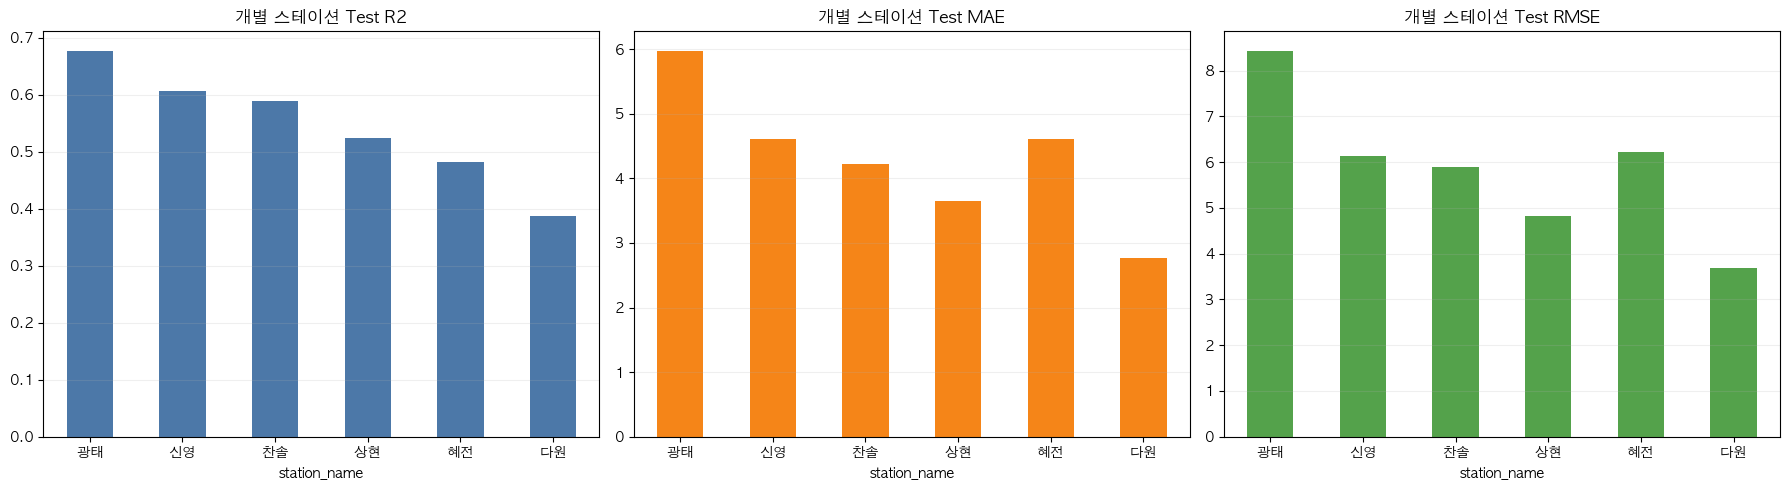

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_df = station_model_results.set_index('station_name')
plot_df['test_R2'].plot(kind='bar', ax=axes[0], color='#4C78A8')
axes[0].set_title('개별 스테이션 Test R2')
axes[0].grid(axis='y', alpha=0.2)
axes[0].tick_params(axis='x', rotation=0)
plot_df['test_MAE'].plot(kind='bar', ax=axes[1], color='#F58518')
axes[1].set_title('개별 스테이션 Test MAE')
axes[1].grid(axis='y', alpha=0.2)
axes[1].tick_params(axis='x', rotation=0)
plot_df['test_RMSE'].plot(kind='bar', ax=axes[2], color='#54A24B')
axes[2].set_title('개별 스테이션 Test RMSE')
axes[2].grid(axis='y', alpha=0.2)
axes[2].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## 6개 스테이션 통합 데이터 구성

이 단계에서는 각 스테이션에서 선택된 대표 월 기반 `train / valid` 데이터만 합친다.
즉 통합 학습은 2024년 전체가 아니라, 월 군집화로 선택된 월의 데이터만 사용한다.

반면 `test`는 2025년 전체 데이터를 그대로 유지한다.
따라서 이 통합 모델은 대표 월만 학습하고도 다음 해 전체 구간에 일반화되는지를 확인하는 실험이다.


In [26]:
combined_train = pd.concat([station_datasets[s]['train'] for s in station_ids], ignore_index=True)
combined_valid = pd.concat([station_datasets[s]['valid'] for s in station_ids], ignore_index=True)
combined_test = pd.concat([station_datasets[s]['test'] for s in station_ids], ignore_index=True)
combined_feature_cols = feature_cols + static_cols + ['station_id']
X_train_combined = pd.get_dummies(combined_train[combined_feature_cols], columns=['station_id'])
X_valid_combined = pd.get_dummies(combined_valid[combined_feature_cols], columns=['station_id'])
X_test_combined = pd.get_dummies(combined_test[combined_feature_cols], columns=['station_id'])
X_valid_combined = X_valid_combined.reindex(columns=X_train_combined.columns, fill_value=0)
X_test_combined = X_test_combined.reindex(columns=X_train_combined.columns, fill_value=0)
y_train_combined = combined_train[target_col]
y_valid_combined = combined_valid[target_col]
y_test_combined = combined_test[target_col]
print('combined_train:', X_train_combined.shape)
print('combined_valid:', X_valid_combined.shape)
print('combined_test:', X_test_combined.shape)


combined_train: (21636, 23)
combined_valid: (9321, 23)
combined_test: (51405, 23)


## 6개 스테이션 통합 RandomForest 학습 및 점수

이 섹션은 선택된 대표 월 기반 통합 학습 데이터를 사용해 `RandomForest`를 학습한다.

여기서 중요한 비교 포인트는 다음과 같다.
- 대표 월만 써도 `test_R2`가 유지되는가
- `train` 대비 `valid/test`가 너무 많이 떨어지지 않는가
- 개별 학습보다 통합 학습이 더 유리한가


In [27]:
combined_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=1),
    param_grid=rf_param_grid,
    scoring='r2',
    cv=search_cv,
    n_jobs=1,
)
combined_search.fit(X_train_combined, y_train_combined)
combined_best_model = combined_search.best_estimator_
combined_pred_train = combined_best_model.predict(X_train_combined)
combined_pred_valid = combined_best_model.predict(X_valid_combined)
combined_pred_test = combined_best_model.predict(X_test_combined)
combined_scores = pd.DataFrame([{
    'scope': '6개 통합',
    'best_params': str(combined_search.best_params_),
    'train_R2': r2_score(y_train_combined, combined_pred_train),
    'valid_R2': r2_score(y_valid_combined, combined_pred_valid),
    'test_R2': r2_score(y_test_combined, combined_pred_test),
    'train_MAE': mean_absolute_error(y_train_combined, combined_pred_train),
    'valid_MAE': mean_absolute_error(y_valid_combined, combined_pred_valid),
    'test_MAE': mean_absolute_error(y_test_combined, combined_pred_test),
    'train_RMSE': mean_squared_error(y_train_combined, combined_pred_train) ** 0.5,
    'valid_RMSE': mean_squared_error(y_valid_combined, combined_pred_valid) ** 0.5,
    'test_RMSE': mean_squared_error(y_test_combined, combined_pred_test) ** 0.5,
}])
display(combined_scores.round(4))


,scope,best_params,train_R2,valid_R2,test_R2,train_MAE,valid_MAE,test_MAE,train_RMSE,valid_RMSE,test_RMSE
0,6개 통합,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",0.8506,0.6979,0.6486,2.6893,3.9953,4.3202,3.7588,5.5282,6.0822


In [28]:
combined_test_with_pred = combined_test[['station_id', 'timestamp', target_col]].copy()
combined_test_with_pred['pred_total_flow'] = combined_pred_test
combined_station_scores = []
for station_id in station_ids:
    station_slice = combined_test_with_pred[combined_test_with_pred['station_id'] == station_id].copy()
    combined_station_scores.append({
        'station_id': station_id,
        'station_name': station_info[station_id],
        'test_R2': r2_score(station_slice[target_col], station_slice['pred_total_flow']),
        'test_MAE': mean_absolute_error(station_slice[target_col], station_slice['pred_total_flow']),
        'test_RMSE': mean_squared_error(station_slice[target_col], station_slice['pred_total_flow']) ** 0.5,
    })
combined_station_scores = pd.DataFrame(combined_station_scores).sort_values('test_R2', ascending=False).reset_index(drop=True)
display(combined_station_scores.round(4))


,station_id,station_name,test_R2,test_MAE,test_RMSE
0,ST-2264,광태,0.6797,5.9661,8.4033
1,ST-1331,찬솔,0.5951,4.1863,5.8469
2,ST-454,신영,0.5464,4.8641,6.5883
3,ST-453,혜전,0.5198,4.4564,5.9905
4,ST-481,상현,0.5128,3.6733,4.8882
5,ST-2425,다원,0.3685,2.7749,3.7375


In [29]:
print('개별 모델 vs 통합 모델 비교용 표')
compare_station_vs_combined = station_model_results[['station_id', 'station_name', 'test_R2', 'test_MAE', 'test_RMSE']].merge(
    combined_station_scores,
    on=['station_id', 'station_name'],
    suffixes=('_individual', '_combined')
)
display(compare_station_vs_combined.round(4))


개별 모델 vs 통합 모델 비교용 표


,station_id,station_name,test_R2_individual,test_MAE_individual,test_RMSE_individual,test_R2_combined,test_MAE_combined,test_RMSE_combined
0,ST-2264,광태,0.6773,5.9767,8.4350,0.6797,5.9661,8.4033
1,ST-454,신영,0.6073,4.6057,6.1298,0.5464,4.8641,6.5883
2,ST-1331,찬솔,0.5882,4.2243,5.8962,0.5951,4.1863,5.8469
3,ST-481,상현,0.5241,3.6512,4.8311,0.5128,3.6733,4.8882
4,ST-453,혜전,0.4828,4.6146,6.2171,0.5198,4.4564,5.9905
5,ST-2425,다원,0.3865,2.7607,3.6836,0.3685,2.7749,3.7375


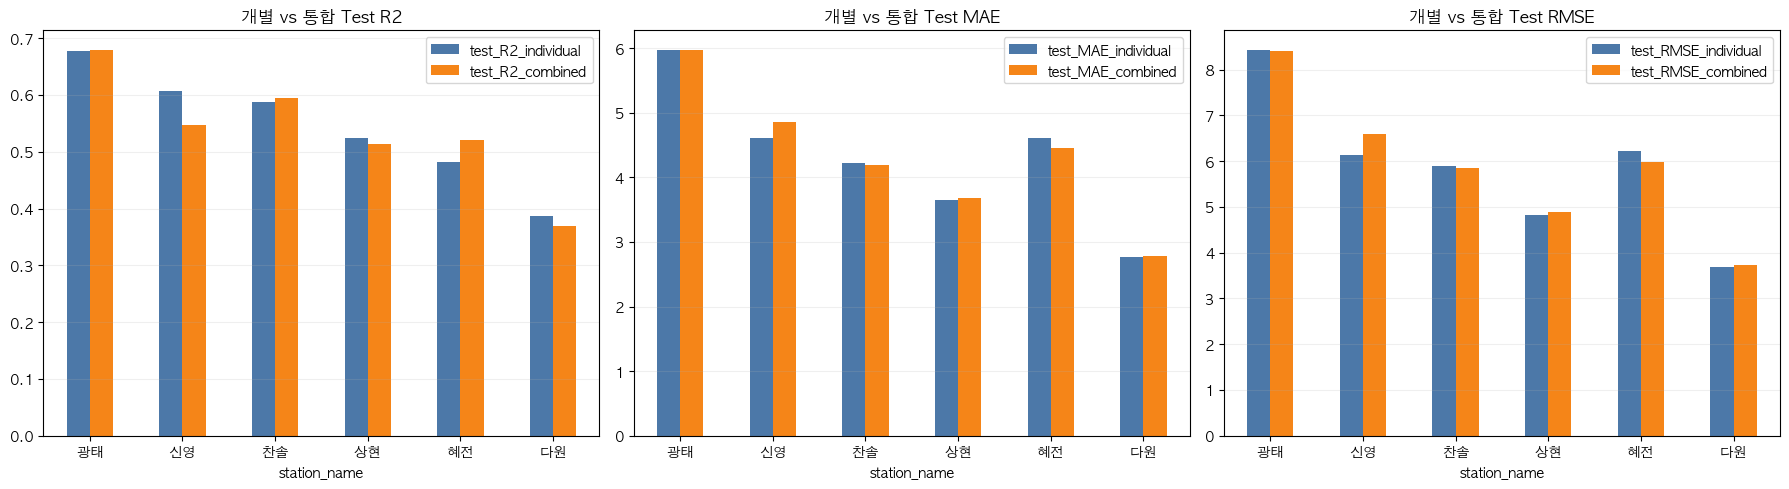

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
compare_df = compare_station_vs_combined.set_index('station_name')
compare_df[['test_R2_individual', 'test_R2_combined']].plot(kind='bar', ax=axes[0], color=['#4C78A8', '#F58518'])
axes[0].set_title('개별 vs 통합 Test R2')
axes[0].grid(axis='y', alpha=0.2)
axes[0].tick_params(axis='x', rotation=0)
compare_df[['test_MAE_individual', 'test_MAE_combined']].plot(kind='bar', ax=axes[1], color=['#4C78A8', '#F58518'])
axes[1].set_title('개별 vs 통합 Test MAE')
axes[1].grid(axis='y', alpha=0.2)
axes[1].tick_params(axis='x', rotation=0)
compare_df[['test_RMSE_individual', 'test_RMSE_combined']].plot(kind='bar', ax=axes[2], color=['#4C78A8', '#F58518'])
axes[2].set_title('개별 vs 통합 Test RMSE')
axes[2].grid(axis='y', alpha=0.2)
axes[2].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## Inflow / Outflow 통합 Baseline

앞에서는 `total_flow`를 기준으로 통합 학습을 확인했다. 이 섹션은 같은 구조에서 타깃만 바꿔 `inflow`와 `outflow`를 따로 예측한다.

이 구간이 필요한 이유는 다음과 같다.
- `total_flow`는 총 이용량을 보기에 좋다.
- 하지만 실제 운영에서는 유입과 유출의 패턴이 다를 수 있다.
- 예를 들어 출근 시간에는 유출이 강하고, 퇴근 시간에는 유입이 강할 수 있다.

따라서 이 결과는 다음을 판단하는 데 사용한다.
- 6개 스테이션을 합쳤을 때 유입량이 더 예측이 쉬운가
- 유출량이 더 불안정한가
- `total_flow`보다 `inflow/outflow`를 직접 타깃으로 두는 것이 나은가


6개 통합 inflow / outflow 점수


,타깃,best_params,train_R2,valid_R2,test_R2,train_MAE,valid_MAE,test_MAE,train_RMSE,valid_RMSE,test_RMSE
0,유입량,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",0.8079,0.6231,0.5873,1.7016,2.4949,2.8328,2.4208,3.4503,4.0806
1,유출량,"{'max_depth': 8, 'min_samples_leaf': 5, 'n_est...",0.6525,0.5980,0.5079,2.3849,2.6494,2.6856,3.2840,3.6538,3.6881


스테이션별 inflow / outflow test 점수


,타깃,station_id,station_name,test_R2,test_MAE,test_RMSE
0,유입량,ST-481,상현,0.4619,2.4215,3.2833
1,유입량,ST-2425,다원,0.4091,1.6518,2.2998
2,유입량,ST-1331,찬솔,0.4692,2.9172,4.2206
3,유입량,ST-454,신영,0.5181,2.9345,3.9912
4,유입량,ST-453,혜전,0.4430,2.8836,4.0175
5,유입량,ST-2264,광태,0.5983,4.1880,5.8270
6,유출량,ST-481,상현,0.3319,2.2418,2.8649
7,유출량,ST-2425,다원,0.3819,1.8578,2.5154
8,유출량,ST-1331,찬솔,0.4654,2.6554,3.7245
9,유출량,ST-454,신영,0.3801,3.0582,4.0117


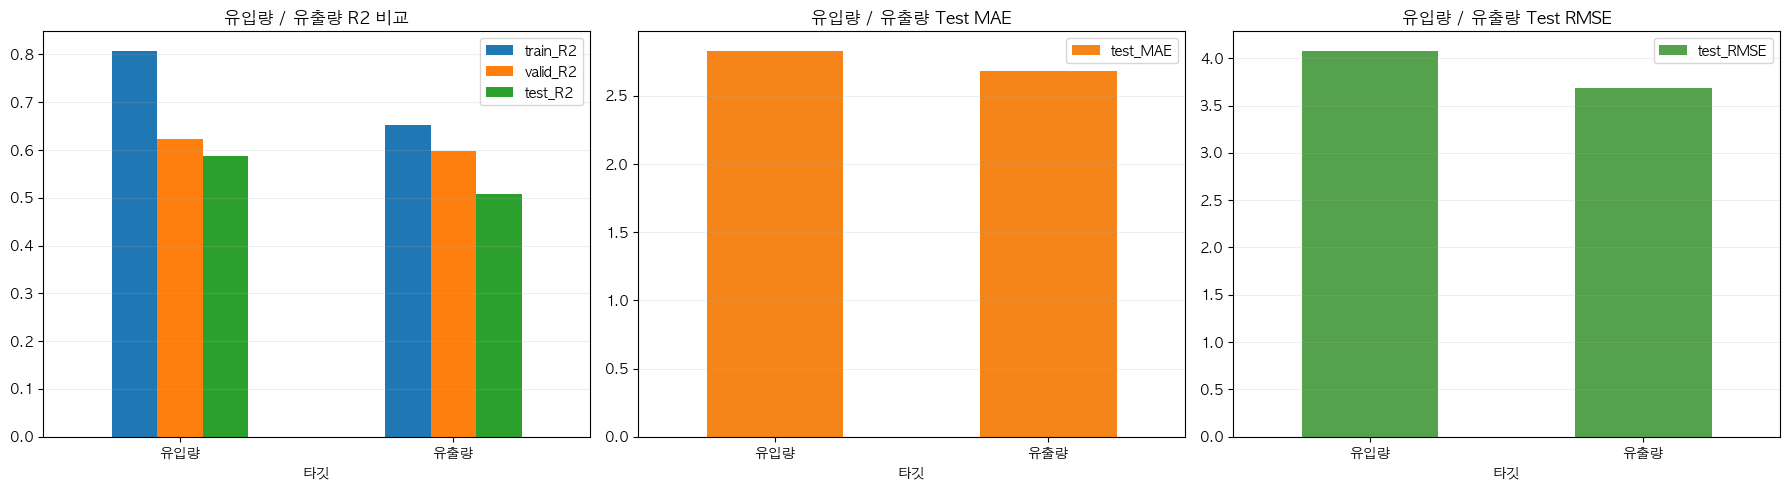

In [31]:
flow_target_results = []
flow_target_station_results = []
flow_target_artifacts = {}

for flow_target in ['inflow', 'outflow']:
    y_train_flow = combined_train[flow_target]
    y_valid_flow = combined_valid[flow_target]
    y_test_flow = combined_test[flow_target]

    flow_search = GridSearchCV(
        estimator=RandomForestRegressor(random_state=42, n_jobs=1),
        param_grid=rf_param_grid,
        scoring='r2',
        cv=search_cv,
        n_jobs=1,
    )
    flow_search.fit(X_train_combined, y_train_flow)
    flow_best_model = flow_search.best_estimator_

    flow_pred_train = flow_best_model.predict(X_train_combined)
    flow_pred_valid = flow_best_model.predict(X_valid_combined)
    flow_pred_test = flow_best_model.predict(X_test_combined)

    flow_target_artifacts[flow_target] = {
        'model': flow_best_model,
        'best_params': flow_search.best_params_,
        'pred_train': flow_pred_train,
        'pred_valid': flow_pred_valid,
        'pred_test': flow_pred_test,
    }

    flow_target_results.append({
        '타깃': flow_target,
        'best_params': str(flow_search.best_params_),
        'train_R2': r2_score(y_train_flow, flow_pred_train),
        'valid_R2': r2_score(y_valid_flow, flow_pred_valid),
        'test_R2': r2_score(y_test_flow, flow_pred_test),
        'train_MAE': mean_absolute_error(y_train_flow, flow_pred_train),
        'valid_MAE': mean_absolute_error(y_valid_flow, flow_pred_valid),
        'test_MAE': mean_absolute_error(y_test_flow, flow_pred_test),
        'train_RMSE': mean_squared_error(y_train_flow, flow_pred_train) ** 0.5,
        'valid_RMSE': mean_squared_error(y_valid_flow, flow_pred_valid) ** 0.5,
        'test_RMSE': mean_squared_error(y_test_flow, flow_pred_test) ** 0.5,
    })

    combined_test_flow = combined_test[['station_id', 'timestamp', flow_target]].copy()
    combined_test_flow['pred_value'] = flow_pred_test
    for station_id in station_ids:
        station_slice = combined_test_flow[combined_test_flow['station_id'] == station_id].copy()
        flow_target_station_results.append({
            '타깃': flow_target,
            'station_id': station_id,
            'station_name': station_info[station_id],
            'test_R2': r2_score(station_slice[flow_target], station_slice['pred_value']),
            'test_MAE': mean_absolute_error(station_slice[flow_target], station_slice['pred_value']),
            'test_RMSE': mean_squared_error(station_slice[flow_target], station_slice['pred_value']) ** 0.5,
        })

flow_target_results = pd.DataFrame(flow_target_results)
flow_target_results['타깃'] = flow_target_results['타깃'].replace({'inflow': '유입량', 'outflow': '유출량'})
print('6개 통합 inflow / outflow 점수')
display(flow_target_results.round(4))

flow_target_station_results = pd.DataFrame(flow_target_station_results)
flow_target_station_results['타깃'] = flow_target_station_results['타깃'].replace({'inflow': '유입량', 'outflow': '유출량'})
print('스테이션별 inflow / outflow test 점수')
display(flow_target_station_results.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_flow = flow_target_results.set_index('타깃')
plot_flow[['train_R2', 'valid_R2', 'test_R2']].plot(kind='bar', ax=axes[0])
axes[0].set_title('유입량 / 유출량 R2 비교')
axes[0].grid(axis='y', alpha=0.2)
axes[0].tick_params(axis='x', rotation=0)

plot_flow[['test_MAE']].plot(kind='bar', ax=axes[1], color='#F58518')
axes[1].set_title('유입량 / 유출량 Test MAE')
axes[1].grid(axis='y', alpha=0.2)
axes[1].tick_params(axis='x', rotation=0)

plot_flow[['test_RMSE']].plot(kind='bar', ax=axes[2], color='#54A24B')
axes[2].set_title('유입량 / 유출량 Test RMSE')
axes[2].grid(axis='y', alpha=0.2)
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## Net Flow 통합 Baseline

이 섹션은 `net_flow = inflow - outflow`를 직접 예측한다.

`net_flow`는 단순 이용량이 아니라, 해당 시간에 스테이션에 자전거가 순증가했는지 순감소했는지를 보는 값이다.
- 양수: 들어온 양이 더 많음
- 음수: 나간 양이 더 많음
- 0 근처: 유입과 유출이 비슷함

이 타깃은 운영 관점에서 중요하다.
- 어느 시간대에 자전거가 빠르게 소진되는지
- 어느 시간대에 자전거가 쌓이는지
- 재배치 필요 방향을 볼 수 있다

주의할 점도 있다.
- `net_flow`는 음수가 가능하므로 `log1p` 변환을 사용하지 않는다.
- `R²`가 `total_flow`보다 낮더라도 이상한 결과는 아니다. `net_flow`는 방향성과 균형 차이를 맞춰야 해서 보통 더 어렵다.


In [32]:
net_target_col = 'net_flow'

y_train_net = combined_train[net_target_col]
y_valid_net = combined_valid[net_target_col]
y_test_net = combined_test[net_target_col]

net_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=1),
    param_grid=rf_param_grid,
    scoring='r2',
    cv=search_cv,
    n_jobs=1,
)
net_search.fit(X_train_combined, y_train_net)
net_best_model = net_search.best_estimator_

net_pred_train = net_best_model.predict(X_train_combined)
net_pred_valid = net_best_model.predict(X_valid_combined)
net_pred_test = net_best_model.predict(X_test_combined)

net_combined_scores = pd.DataFrame([{
    'scope': '6개 통합 net_flow',
    'best_params': str(net_search.best_params_),
    'train_R2': r2_score(y_train_net, net_pred_train),
    'valid_R2': r2_score(y_valid_net, net_pred_valid),
    'test_R2': r2_score(y_test_net, net_pred_test),
    'train_MAE': mean_absolute_error(y_train_net, net_pred_train),
    'valid_MAE': mean_absolute_error(y_valid_net, net_pred_valid),
    'test_MAE': mean_absolute_error(y_test_net, net_pred_test),
    'train_RMSE': mean_squared_error(y_train_net, net_pred_train) ** 0.5,
    'valid_RMSE': mean_squared_error(y_valid_net, net_pred_valid) ** 0.5,
    'test_RMSE': mean_squared_error(y_test_net, net_pred_test) ** 0.5,
}])
print('6개 통합 net_flow 점수')
display(net_combined_scores.round(4))

combined_test_net = combined_test[['station_id', 'timestamp', net_target_col]].copy()
combined_test_net['pred_net_flow'] = net_pred_test
net_station_scores = []
for station_id in station_ids:
    station_slice = combined_test_net[combined_test_net['station_id'] == station_id].copy()
    net_station_scores.append({
        'station_id': station_id,
        'station_name': station_info[station_id],
        'test_R2': r2_score(station_slice[net_target_col], station_slice['pred_net_flow']),
        'test_MAE': mean_absolute_error(station_slice[net_target_col], station_slice['pred_net_flow']),
        'test_RMSE': mean_squared_error(station_slice[net_target_col], station_slice['pred_net_flow']) ** 0.5,
    })
net_station_scores = pd.DataFrame(net_station_scores).sort_values('test_R2', ascending=False).reset_index(drop=True)
print('스테이션별 net_flow test 점수')
display(net_station_scores.round(4))


6개 통합 net_flow 점수


,scope,best_params,train_R2,valid_R2,test_R2,train_MAE,valid_MAE,test_MAE,train_RMSE,valid_RMSE,test_RMSE
0,6개 통합 net_flow,"{'max_depth': 8, 'min_samples_leaf': 1, 'n_est...",0.4291,0.3463,0.2291,2.9091,3.1024,3.413,4.0346,4.3117,4.8637


스테이션별 net_flow test 점수


,station_id,station_name,test_R2,test_MAE,test_RMSE
0,ST-2425,다원,0.3629,2.3039,3.2184
1,ST-453,혜전,0.3192,3.5722,4.9558
2,ST-1331,찬솔,0.2095,3.6359,5.2282
3,ST-2264,광태,0.2031,4.6690,6.5530
4,ST-481,상현,0.0346,2.8384,3.8793
5,ST-454,신영,0.0300,3.4584,4.6567


## Net Flow 직접 예측 vs 유입/유출 차이 비교

`net_flow`는 직접 하나의 모델로 예측할 수도 있고, `inflow`와 `outflow`를 각각 예측한 뒤 두 예측값의 차이로 계산할 수도 있다.

이 섹션은 두 접근을 같은 기준으로 비교한다.
- 직접 예측: `net_flow`를 바로 학습
- 간접 계산: `pred_inflow - pred_outflow`

이 비교를 통해 다음을 확인한다.
- 직접 `net_flow` 예측이 실제로 더 어려운지
- `inflow/outflow` 두 모델로 분리하는 것이 더 안정적인지
- 스테이션별로 어느 방식이 더 나은지


net_flow 직접 예측 vs 유입/유출 차이 비교


,방식,train_R2,valid_R2,test_R2,train_MAE,valid_MAE,test_MAE,train_RMSE,valid_RMSE,test_RMSE
0,직접 net_flow 예측,0.4291,0.3463,0.2291,2.9091,3.1024,3.4130,4.0346,4.3117,4.8637
1,유입-유출 차이로 계산,0.4932,0.2977,0.2332,2.7436,3.2010,3.4283,3.8016,4.4689,4.8508


스테이션별 net_flow 비교 점수


,방식,station_id,station_name,test_R2,test_MAE,test_RMSE
0,직접 net_flow 예측,ST-481,상현,0.0346,2.8384,3.8793
1,유입-유출 차이로 계산,ST-481,상현,0.0555,2.7888,3.8370
2,직접 net_flow 예측,ST-2425,다원,0.3629,2.3039,3.2184
3,유입-유출 차이로 계산,ST-2425,다원,0.3931,2.2958,3.1411
4,직접 net_flow 예측,ST-1331,찬솔,0.2095,3.6359,5.2282
5,유입-유출 차이로 계산,ST-1331,찬솔,0.2076,3.6831,5.2346
6,직접 net_flow 예측,ST-454,신영,0.0300,3.4584,4.6567
7,유입-유출 차이로 계산,ST-454,신영,-0.0100,3.5547,4.7517
8,직접 net_flow 예측,ST-453,혜전,0.3192,3.5722,4.9558
9,유입-유출 차이로 계산,ST-453,혜전,0.3344,3.5462,4.9002


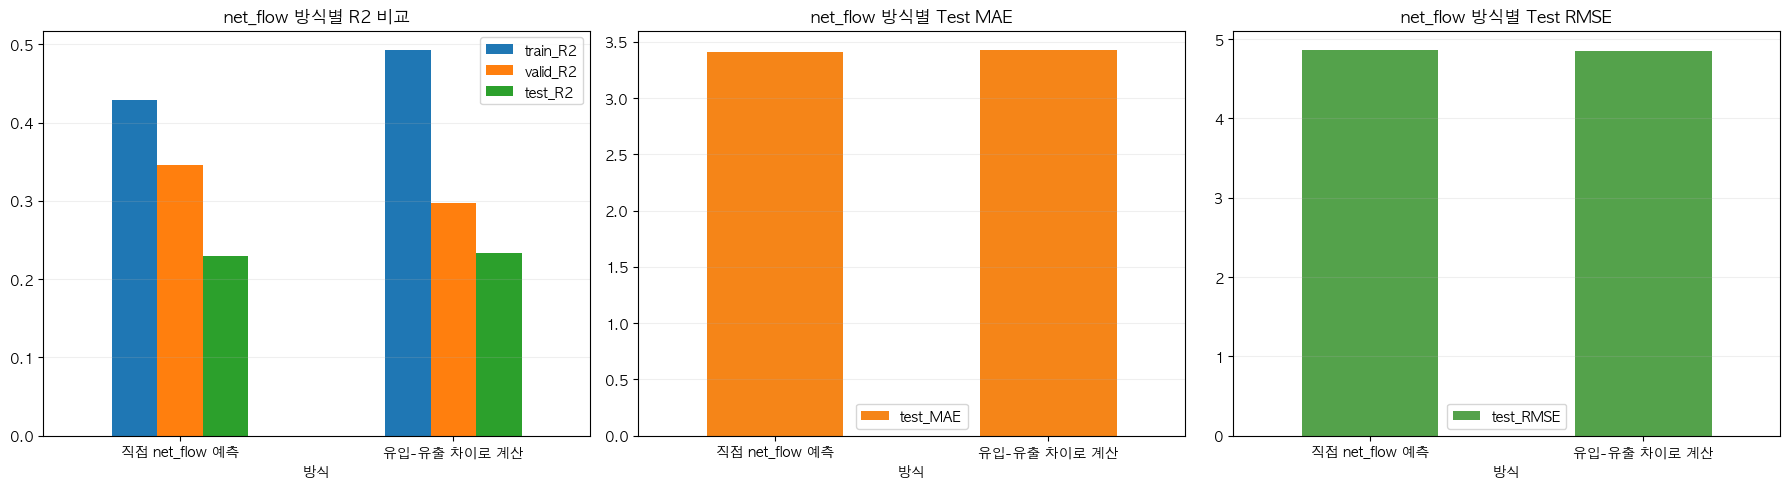

In [33]:
derived_net_pred_train = flow_target_artifacts['inflow']['pred_train'] - flow_target_artifacts['outflow']['pred_train']
derived_net_pred_valid = flow_target_artifacts['inflow']['pred_valid'] - flow_target_artifacts['outflow']['pred_valid']
derived_net_pred_test = flow_target_artifacts['inflow']['pred_test'] - flow_target_artifacts['outflow']['pred_test']

net_compare_scores = pd.DataFrame([
    {
        '방식': '직접 net_flow 예측',
        'train_R2': r2_score(y_train_net, net_pred_train),
        'valid_R2': r2_score(y_valid_net, net_pred_valid),
        'test_R2': r2_score(y_test_net, net_pred_test),
        'train_MAE': mean_absolute_error(y_train_net, net_pred_train),
        'valid_MAE': mean_absolute_error(y_valid_net, net_pred_valid),
        'test_MAE': mean_absolute_error(y_test_net, net_pred_test),
        'train_RMSE': mean_squared_error(y_train_net, net_pred_train) ** 0.5,
        'valid_RMSE': mean_squared_error(y_valid_net, net_pred_valid) ** 0.5,
        'test_RMSE': mean_squared_error(y_test_net, net_pred_test) ** 0.5,
    },
    {
        '방식': '유입-유출 차이로 계산',
        'train_R2': r2_score(y_train_net, derived_net_pred_train),
        'valid_R2': r2_score(y_valid_net, derived_net_pred_valid),
        'test_R2': r2_score(y_test_net, derived_net_pred_test),
        'train_MAE': mean_absolute_error(y_train_net, derived_net_pred_train),
        'valid_MAE': mean_absolute_error(y_valid_net, derived_net_pred_valid),
        'test_MAE': mean_absolute_error(y_test_net, derived_net_pred_test),
        'train_RMSE': mean_squared_error(y_train_net, derived_net_pred_train) ** 0.5,
        'valid_RMSE': mean_squared_error(y_valid_net, derived_net_pred_valid) ** 0.5,
        'test_RMSE': mean_squared_error(y_test_net, derived_net_pred_test) ** 0.5,
    },
])
print('net_flow 직접 예측 vs 유입/유출 차이 비교')
display(net_compare_scores.round(4))

combined_test_net_compare = combined_test[['station_id', 'timestamp', net_target_col]].copy()
combined_test_net_compare['pred_direct_net_flow'] = net_pred_test
combined_test_net_compare['pred_derived_net_flow'] = derived_net_pred_test

net_compare_station_rows = []
for station_id in station_ids:
    station_slice = combined_test_net_compare[combined_test_net_compare['station_id'] == station_id].copy()
    net_compare_station_rows.append({
        '방식': '직접 net_flow 예측',
        'station_id': station_id,
        'station_name': station_info[station_id],
        'test_R2': r2_score(station_slice[net_target_col], station_slice['pred_direct_net_flow']),
        'test_MAE': mean_absolute_error(station_slice[net_target_col], station_slice['pred_direct_net_flow']),
        'test_RMSE': mean_squared_error(station_slice[net_target_col], station_slice['pred_direct_net_flow']) ** 0.5,
    })
    net_compare_station_rows.append({
        '방식': '유입-유출 차이로 계산',
        'station_id': station_id,
        'station_name': station_info[station_id],
        'test_R2': r2_score(station_slice[net_target_col], station_slice['pred_derived_net_flow']),
        'test_MAE': mean_absolute_error(station_slice[net_target_col], station_slice['pred_derived_net_flow']),
        'test_RMSE': mean_squared_error(station_slice[net_target_col], station_slice['pred_derived_net_flow']) ** 0.5,
    })

net_compare_station_scores = pd.DataFrame(net_compare_station_rows)
print('스테이션별 net_flow 비교 점수')
display(net_compare_station_scores.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_net_compare = net_compare_scores.set_index('방식')
plot_net_compare[['train_R2', 'valid_R2', 'test_R2']].plot(kind='bar', ax=axes[0])
axes[0].set_title('net_flow 방식별 R2 비교')
axes[0].grid(axis='y', alpha=0.2)
axes[0].tick_params(axis='x', rotation=0)

plot_net_compare[['test_MAE']].plot(kind='bar', ax=axes[1], color='#F58518')
axes[1].set_title('net_flow 방식별 Test MAE')
axes[1].grid(axis='y', alpha=0.2)
axes[1].tick_params(axis='x', rotation=0)

plot_net_compare[['test_RMSE']].plot(kind='bar', ax=axes[2], color='#54A24B')
axes[2].set_title('net_flow 방식별 Test RMSE')
axes[2].grid(axis='y', alpha=0.2)
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## 통합 모델 비교

마지막 섹션은 같은 통합 데이터 분할을 유지한 채 여러 모델을 한 번에 비교한다.

비교 모델은 다음과 같다.
- `LinearRegression`
- `RidgeCV`
- `LassoCV`
- `ElasticNetCV`
- `RandomForest`
- `HistGradientBoostingRegressor`
- `XGBoost` 가능 시 포함

비교 목적은 다음과 같다.
- 선형 모델만으로도 충분한지 확인한다.
- 규제 모델이 과적합을 줄이는지 본다.
- 트리/부스팅 모델이 비선형 패턴을 더 잘 잡는지 확인한다.

결과를 해석할 때는 다음 순서를 권장한다.
1. `test_R2`가 가장 높은 모델을 본다.
2. 그다음 `valid_R2`와 `train_test_gap`을 같이 본다.
3. `MAE`, `RMSE`로 실제 오차 크기가 허용 가능한지도 확인한다.

즉 이 섹션은 단순히 최고 점수 하나를 고르는 것이 아니라, 일반화 성능이 가장 안정적인 모델을 찾기 위한 비교 구간이다.


통합 모델 비교 전체 표


,모델,best_params,train_R2,valid_R2,test_R2,train_MAE,valid_MAE,test_MAE,train_RMSE,valid_RMSE,test_RMSE,train_test_gap,valid_test_gap
0,HGB,"{'l2_regularization': 3.0, 'learning_rate': 0....",0.7628,0.7033,0.6648,3.4683,3.9890,4.2352,4.7361,5.4786,5.9405,0.0980,0.0385
1,XGBoost,"{'subsample': 0.7, 'reg_lambda': 1.0, 'n_estim...",0.7732,0.7061,0.6622,3.4010,3.9719,4.2796,4.6310,5.4521,5.9639,0.1111,0.0440
2,RandomForest,"{'max_depth': 8, 'max_features': 0.8, 'min_sam...",0.7133,0.6609,0.6256,3.7543,4.2427,4.4353,5.2072,5.8567,6.2787,0.0877,0.0353
3,LassoCV,{'alpha': 0.3039195382313198},0.3758,0.4078,0.3631,5.6174,5.6670,5.8383,7.6835,7.7396,8.1889,0.0127,0.0448
4,ElasticNetCV,"{'alpha': 0.3039195382313198, 'l1_ratio': 0.9}",0.3752,0.4071,0.3618,5.6186,5.6675,5.8417,7.6873,7.7443,8.1969,0.0133,0.0453
5,LinearRegression,{'model': 'baseline'},0.3937,0.4278,0.3491,5.5835,5.6393,5.8954,7.5722,7.6081,8.2780,0.0446,0.0786
6,RidgeCV,{'alpha': 0.4893900918477494},0.3937,0.4278,0.3491,5.5834,5.6392,5.8949,7.5722,7.6081,8.2781,0.0446,0.0787


모델별 최적 파라미터


,모델,best_params
0,HGB,"{'l2_regularization': 3.0, 'learning_rate': 0...."
1,XGBoost,"{'subsample': 0.7, 'reg_lambda': 1.0, 'n_estim..."
2,RandomForest,"{'max_depth': 8, 'max_features': 0.8, 'min_sam..."
3,LassoCV,{'alpha': 0.3039195382313198}
4,ElasticNetCV,"{'alpha': 0.3039195382313198, 'l1_ratio': 0.9}"
5,LinearRegression,{'model': 'baseline'}
6,RidgeCV,{'alpha': 0.4893900918477494}


일반화 격차 확인


,모델,train_R2,valid_R2,test_R2,train_test_gap,valid_test_gap
0,HGB,0.7628,0.7033,0.6648,0.0980,0.0385
1,XGBoost,0.7732,0.7061,0.6622,0.1111,0.0440
2,RandomForest,0.7133,0.6609,0.6256,0.0877,0.0353
3,LassoCV,0.3758,0.4078,0.3631,0.0127,0.0448
4,ElasticNetCV,0.3752,0.4071,0.3618,0.0133,0.0453
5,LinearRegression,0.3937,0.4278,0.3491,0.0446,0.0786
6,RidgeCV,0.3937,0.4278,0.3491,0.0446,0.0787


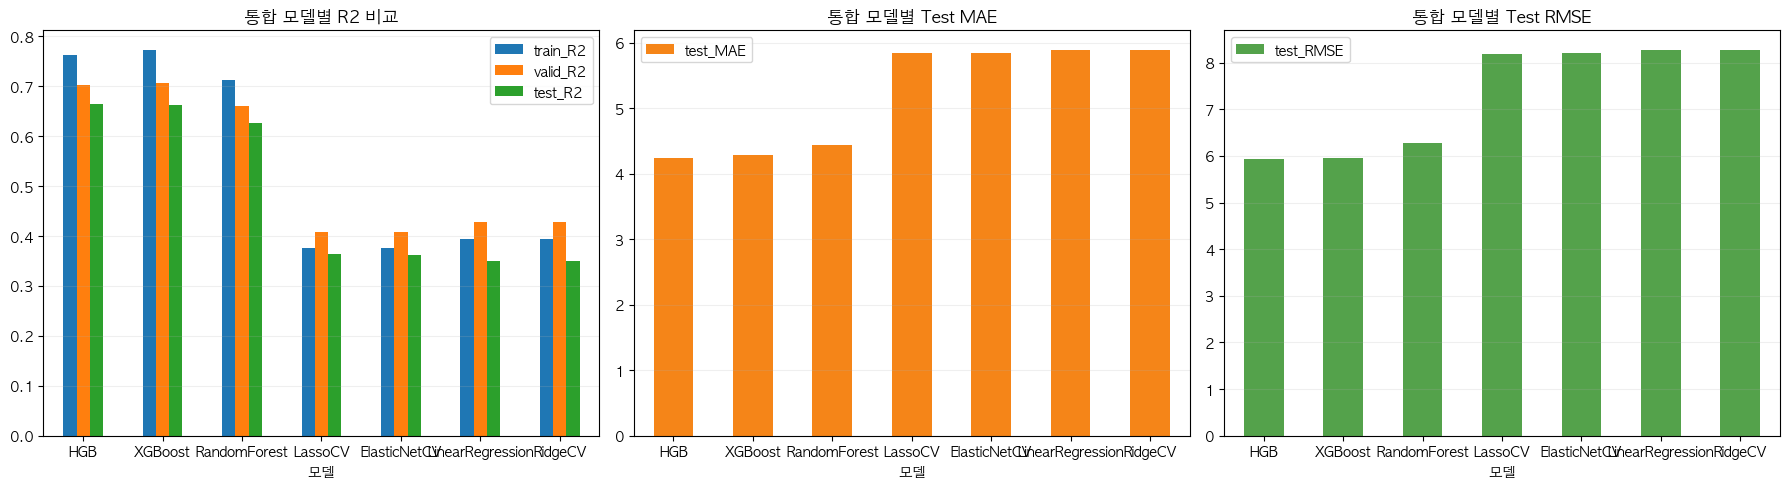

In [34]:
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit

try:
    from xgboost import XGBRegressor
    xgb_available = True
except Exception:
    xgb_available = False

compare_target = 'total_flow'
compare_cv = TimeSeriesSplit(n_splits=3)
alpha_grid = np.logspace(-3, 3, 30)

combined_model_space = {
    'LinearRegression': {
        'estimator': make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), LinearRegression()),
        'search_type': 'none',
    },
    'RidgeCV': {
        'estimator': make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), RidgeCV(alphas=alpha_grid)),
        'search_type': 'none',
    },
    'LassoCV': {
        'estimator': make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), LassoCV(alphas=alpha_grid, max_iter=20000)),
        'search_type': 'none',
    },
    'ElasticNetCV': {
        'estimator': make_pipeline(
            SimpleImputer(strategy='median'),
            StandardScaler(),
            ElasticNetCV(alphas=alpha_grid, l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], max_iter=20000)
        ),
        'search_type': 'none',
    },
    'RandomForest': {
        'estimator': RandomForestRegressor(random_state=42, n_jobs=1),
        'search_type': 'grid',
        'param_grid': {
            'n_estimators': [200, 400],
            'max_depth': [4, 6, 8],
            'min_samples_leaf': [10, 20, 30],
            'max_features': ['sqrt', 0.8],
        },
    },
    'HGB': {
        'estimator': HistGradientBoostingRegressor(random_state=42),
        'search_type': 'grid',
        'param_grid': {
            'learning_rate': [0.03, 0.05],
            'max_iter': [200, 300],
            'max_depth': [3, 4, 5],
            'min_samples_leaf': [20, 30, 40],
            'l2_regularization': [0.0, 1.0, 3.0],
        },
    },
}

if xgb_available:
    combined_model_space['XGBoost'] = {
        'estimator': XGBRegressor(random_state=42, objective='reg:squarederror', n_jobs=1),
        'search_type': 'random',
        'param_grid': {
            'n_estimators': [150, 250, 400],
            'max_depth': [3, 4, 5],
            'learning_rate': [0.03, 0.05, 0.08],
            'subsample': [0.7, 0.8, 0.9],
            'colsample_bytree': [0.7, 0.8, 0.9],
            'min_child_weight': [3, 5, 7],
            'reg_lambda': [1.0, 3.0, 5.0],
        },
        'n_iter': 12,
    }

combined_compare_results = []
combined_compare_artifacts = {}

for model_name, config in combined_model_space.items():
    estimator = clone(config['estimator'])
    if config['search_type'] == 'none':
        fitted_model = estimator.fit(X_train_combined, y_train_combined)
        best_model = fitted_model
        if model_name == 'LinearRegression':
            best_params = {'model': 'baseline'}
        elif model_name == 'RidgeCV':
            best_params = {'alpha': float(fitted_model.named_steps['ridgecv'].alpha_)}
        elif model_name == 'LassoCV':
            best_params = {'alpha': float(fitted_model.named_steps['lassocv'].alpha_)}
        else:
            best_params = {
                'alpha': float(fitted_model.named_steps['elasticnetcv'].alpha_),
                'l1_ratio': float(fitted_model.named_steps['elasticnetcv'].l1_ratio_),
            }
    elif config['search_type'] == 'grid':
        search = GridSearchCV(
            estimator=estimator,
            param_grid=config['param_grid'],
            scoring='r2',
            cv=compare_cv,
            n_jobs=1,
        )
        search.fit(X_train_combined, y_train_combined)
        best_model = search.best_estimator_
        best_params = search.best_params_
    else:
        search = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=config['param_grid'],
            n_iter=config['n_iter'],
            scoring='r2',
            cv=compare_cv,
            n_jobs=1,
            random_state=42,
        )
        search.fit(X_train_combined, y_train_combined)
        best_model = search.best_estimator_
        best_params = search.best_params_

    pred_train = best_model.predict(X_train_combined)
    pred_valid = best_model.predict(X_valid_combined)
    pred_test = best_model.predict(X_test_combined)

    combined_compare_artifacts[model_name] = {
        'best_model': best_model,
        'best_params': best_params,
        'pred_train': pred_train,
        'pred_valid': pred_valid,
        'pred_test': pred_test,
    }

    combined_compare_results.append({
        '모델': model_name,
        'best_params': str(best_params),
        'train_R2': r2_score(y_train_combined, pred_train),
        'valid_R2': r2_score(y_valid_combined, pred_valid),
        'test_R2': r2_score(y_test_combined, pred_test),
        'train_MAE': mean_absolute_error(y_train_combined, pred_train),
        'valid_MAE': mean_absolute_error(y_valid_combined, pred_valid),
        'test_MAE': mean_absolute_error(y_test_combined, pred_test),
        'train_RMSE': mean_squared_error(y_train_combined, pred_train) ** 0.5,
        'valid_RMSE': mean_squared_error(y_valid_combined, pred_valid) ** 0.5,
        'test_RMSE': mean_squared_error(y_test_combined, pred_test) ** 0.5,
    })

combined_compare_results = pd.DataFrame(combined_compare_results).sort_values('test_R2', ascending=False).reset_index(drop=True)
combined_compare_results['train_test_gap'] = combined_compare_results['train_R2'] - combined_compare_results['test_R2']
combined_compare_results['valid_test_gap'] = combined_compare_results['valid_R2'] - combined_compare_results['test_R2']

print('통합 모델 비교 전체 표')
display(combined_compare_results.round(4))
print('모델별 최적 파라미터')
display(combined_compare_results[['모델', 'best_params']])
print('일반화 격차 확인')
display(combined_compare_results[['모델', 'train_R2', 'valid_R2', 'test_R2', 'train_test_gap', 'valid_test_gap']].round(4))

plot_df = combined_compare_results.set_index('모델')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_df[['train_R2', 'valid_R2', 'test_R2']].plot(kind='bar', ax=axes[0])
axes[0].set_title('통합 모델별 R2 비교')
axes[0].grid(axis='y', alpha=0.2)
axes[0].tick_params(axis='x', rotation=0)

plot_df[['test_MAE']].plot(kind='bar', ax=axes[1], color='#F58518')
axes[1].set_title('통합 모델별 Test MAE')
axes[1].grid(axis='y', alpha=0.2)
axes[1].tick_params(axis='x', rotation=0)

plot_df[['test_RMSE']].plot(kind='bar', ax=axes[2], color='#54A24B')
axes[2].set_title('통합 모델별 Test RMSE')
axes[2].grid(axis='y', alpha=0.2)
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## 읽는 순서와 해석 가이드

이 파일은 `월 군집화 -> 대표 월 선택 -> 선택 월 기반 train/valid -> 2025 전체 test` 흐름으로 읽으면 된다.

핵심 확인 포인트는 다음과 같다.
1. `selected_months_df`에서 어떤 월이 선택됐는지 확인한다.
2. `station_split_summary`에서 선택 월 기준 행 수가 충분한지 본다.
3. 개별 스테이션과 통합 모델의 `test_R2`를 비교한다.
4. `inflow`, `outflow`, `net_flow` 중 어떤 타깃이 상대적으로 안정적인지 본다.
5. 마지막 모델 비교표에서 선택 월 기반 통합 학습에 가장 맞는 모델을 고른다.
